# 基于Lasso回归的气温预测模型

## 项目概述
本项目使用 **Lasso回归**（L1正则化线性模型）对加州欧文市2014年每日气温进行预测，核心优势：
- **数据集**：Irvine Daily Weather Data（含7个气象特征，无缺失值）
- **模型**：Lasso自动筛选关键气象特征，避免过拟合
- **调优**：GridSearchCV网格搜索 + 5折交叉验证
- **评估**：MSE、RMSE、R² 量化预测精度

下面简要介绍Lasso回归与气温预测的意义，为方法选择做铺垫。

## Lasso回归简介
**Lasso回归**是在普通线性回归基础上加入L1正则化的模型，它能在保证拟合效果的同时压缩系数，并将不重要的特征系数收缩为0，从而实现自动特征选择、提升可解释性并抑制过拟合。

## 气温预测意义
将Lasso用于气温预测的意义在于：它能在多种气象变量中筛出关键驱动因素，减少冗余特征带来的噪声，提高模型稳定性与泛化能力，同时便于解释“哪些因素在影响气温”，为天气分析与业务决策提供清晰依据。

接下来进入实操部分，从导入依赖开始。

## 1. 导入核心依赖库

本节导入数据分析与建模所需库，并设置绘图中文环境。

In [263]:
# 1. 导入核心依赖库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 配置Matplotlib中文显示（避免标签乱码）
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常

print("✅ 环境配置完成！")

plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]  # 优先用SimHei
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

✅ 环境配置完成！


环境配置完成后，开始加载数据并进行基础预处理。

## 2. 数据加载与预处理

本节读取本地或在线数据，并自动适配可用的数值特征。

In [264]:
# 2. 加载Irvine每日气象数据（优先从本地加载，不存在则在线下载）
import os
from pathlib import Path

# 定义数据路径
data_dir = Path(r"D:\xiangmu\7-qiwen\data")
data_path = data_dir / "weather.csv"

# 确保data目录存在
data_dir.mkdir(parents=True, exist_ok=True)

# 优先从本地加载，不存在则在线下载并保存
if data_path.exists():
    print(f"📂 从本地加载数据：{data_path}")
    df = pd.read_csv(data_path)
else:
    print(f"🌐 本地数据不存在，从在线下载...")
    url = "https://raw.githubusercontent.com/vega/vega-datasets/master/data/weather.csv"
    df = pd.read_csv(url)
    # 保存到本地
    df.to_csv(data_path, index=False)

# 先查看数据集的列名和结构

# 数据预处理：选择核心特征与目标变量（根据实际数据集调整列名）
# 原始数据集可能使用不同的列名，需要映射
# 常见列名：temp_min->min_temp, temp_max->max_temp, wind->avg_wind等
feature_cols = ["temp_min", "temp_max", "wind", "weather"]  # 根据实际列名调整
target_col = "temp_max"  # 使用最高温度作为预测目标

# 先检查哪些列存在
available_cols = [col for col in feature_cols + [target_col] if col in df.columns]

# 使用数值型列作为特征
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 重新定义特征和目标（使用实际存在的数值列）
if 'temp_max' in numeric_df.columns:
    target_col = 'temp_max'
    feature_cols = [col for col in numeric_df.columns if col != target_col]
    df = numeric_df.dropna()
    
    print(f"\n数据集前5行：")
    display(df.head())
else:
    print("\n⚠️ 数据集结构与预期不符，显示前5行数据：")
    display(df.head())

📂 从本地加载数据：D:\xiangmu\7-qiwen\data\weather.csv

数据集前5行：


,precipitation,temp_max,temp_min,wind
0,0.0,12.8,5.0,4.7
1,10.9,10.6,2.8,4.5
2,0.8,11.7,7.2,2.3
3,20.3,12.2,5.6,4.7
4,1.3,8.9,2.8,6.1


完成数据读取后，进入训练/测试集划分与标准化步骤。

## 3. 数据集划分与标准化

Lasso对尺度敏感，因此需要标准化；这里同时完成训练集/测试集划分。

In [265]:
# 3. 数据集划分与标准化
# 划分特征矩阵X与目标变量y
X = df[feature_cols]
y = df[target_col]

# 划分训练集/测试集（8:2分割）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 特征标准化（Lasso对特征尺度敏感，必须标准化）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 训练集拟合+转换
X_test_scaled = scaler.transform(X_test)        # 测试集仅转换

print(f"✅ 数据准备完成！")
print(f"训练集：{X_train.shape[0]} 样本 | 测试集：{X_test.shape[0]} 样本")
print(f"特征列表：{feature_cols}")

✅ 数据准备完成！
训练集：2337 样本 | 测试集：585 样本
特征列表：['precipitation', 'temp_min', 'wind']


数据准备好后，进行Lasso超参数搜索与交叉验证。

## 4. Lasso模型调优

通过网格搜索寻找最优的正则化强度alpha。

In [266]:
# 4. Lasso回归模型调优（GridSearchCV网格搜索 + 5折交叉验证）
# 定义参数搜索范围，覆盖弱/中/强正则化强度
param_grid = {"alpha": [0.001, 0.01, 0.1, 0.5, 1, 5, 10]}

# 初始化网格搜索，以R²为评分标准
grid_search = GridSearchCV(
    estimator=Lasso(random_state=42, fit_intercept=True),
    param_grid=param_grid,
    cv=5,          # 5折交叉验证
    scoring="r2",  # 回归任务核心评分指标
    n_jobs=-1      # 利用所有CPU核心加速
)

# 训练并寻优
grid_search.fit(X_train_scaled, y_train)

# 获取最优模型与最优参数
best_lasso = grid_search.best_estimator_
best_alpha = grid_search.best_params_["alpha"]

print(f"✅ 最优正则化参数alpha：{best_alpha}")
print(f"✅ 训练集5折交叉验证最优R²：{grid_search.best_score_:.4f}")

✅ 最优正则化参数alpha：0.01
✅ 训练集5折交叉验证最优R²：0.8650


得到最优模型后，对测试集进行预测并评估效果。

## 5. 模型预测与评估

使用MSE、RMSE和R²衡量预测性能。

In [267]:
# 5. 模型预测与量化评估
y_pred = best_lasso.predict(X_test_scaled)

# 计算核心评估指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)  # 均方根误差，与气温同量纲，更易解读

# 打印评估结果
print("="*60)
print("📊 模型测试集评估结果")
print("="*60)
print(f"均方误差（MSE）：{mse:.2f}")
print(f"均方根误差（RMSE）：{rmse:.2f} ℃（与气温同量纲）")
print(f"决定系数（R²）：{r2:.4f}（越接近1，模型拟合效果越好）")

📊 模型测试集评估结果
均方误差（MSE）：9.74
均方根误差（RMSE）：3.12 ℃（与气温同量纲）
决定系数（R²）：0.8715（越接近1，模型拟合效果越好）


评估完成后，用可视化直观对比真实与预测效果。

## 6. 预测结果可视化

将展示折线对比和散点拟合两类图形。

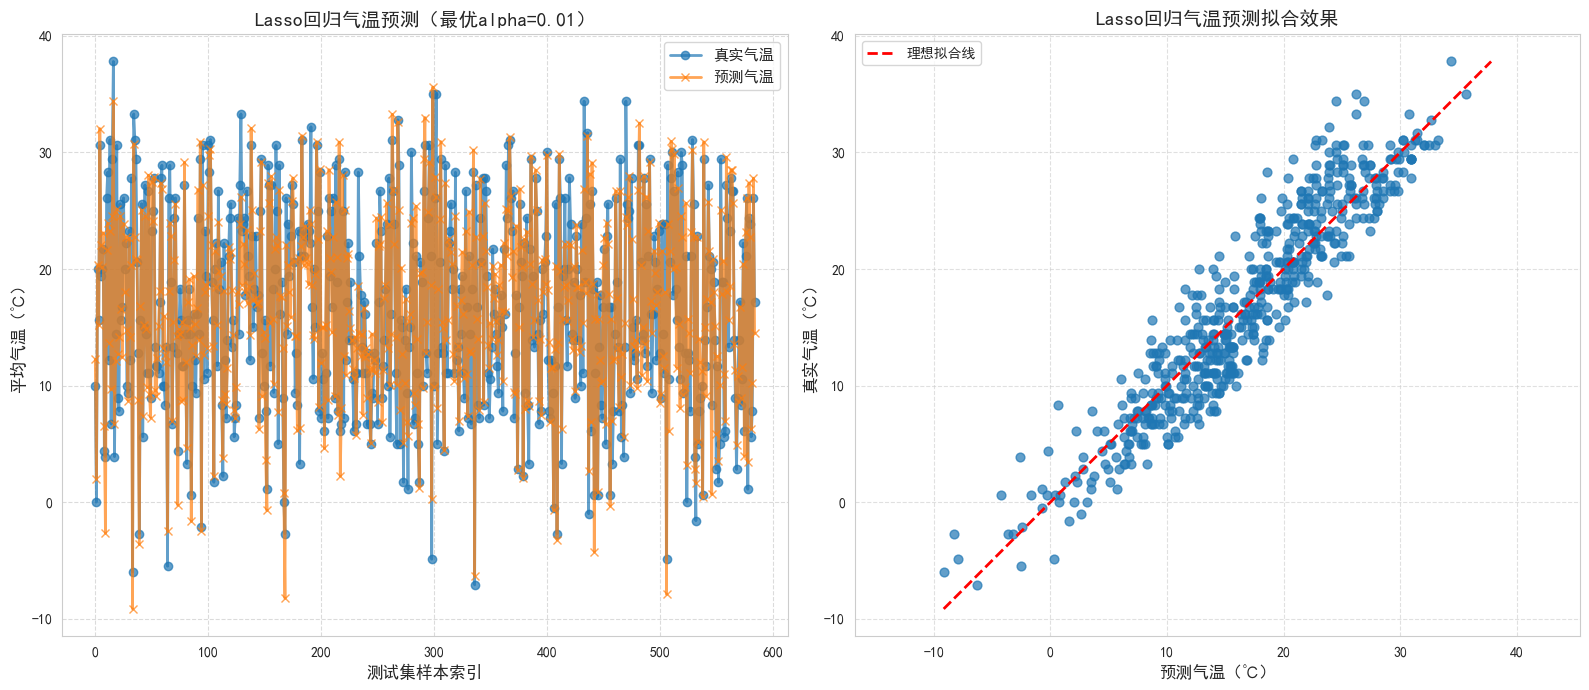

In [268]:
# 6. 可视化 - Lasso回归气温预测双图展示（折线对比+散点拟合）
import warnings
import matplotlib.pyplot as plt
import numpy as np

# 全局配置：屏蔽警告+中文显示+负号正常显示
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据预处理：统一转为一维numpy数组，解决维度/类型不匹配问题
x_idx = np.arange(len(y_test))
y_test_array = np.array(y_test).flatten() if hasattr(y_test, 'flatten') else np.array(y_test.values)
y_pred_array = np.array(y_pred).flatten() if hasattr(y_pred, 'flatten') else np.array(y_pred)

# ========== 子图1：真实气温 vs 预测气温 折线对比图 ==========
plt.figure(figsize=(16, 7))  # 宽幅画布，适配双图展示

plt.subplot(1, 2, 1)  # 1行2列，第1个子图
plt.plot(x_idx, y_test_array, label="真实气温", marker="o", color="#1f77b4", 
         linewidth=2, markersize=6, alpha=0.7)
plt.plot(x_idx, y_pred_array, label="预测气温", marker="x", color="#ff7f0e", 
         linewidth=2, markersize=6, alpha=0.7)
plt.title(f"Lasso回归气温预测（最优alpha={best_alpha}）", fontsize=14, fontweight="bold")
plt.xlabel("测试集样本索引", fontsize=12)
plt.ylabel("平均气温（℃）", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

# ========== 子图2：真实气温 vs 预测气温 散点拟合图 ==========
plt.subplot(1, 2, 2)  # 1行2列，第2个子图
# 绘制散点：与示例一致的蓝色+透明度
plt.scatter(y_pred_array, y_test_array, color='#1f77b4', alpha=0.7, s=40)
# 绘制理想拟合线（y=x）：红色虚线，标注图例
min_val = min(y_test_array.min(), y_pred_array.min())
max_val = max(y_test_array.max(), y_pred_array.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linestyle='--', linewidth=2, label='理想拟合线')
plt.title('Lasso回归气温预测拟合效果', fontsize=14, fontweight='bold')
plt.xlabel('预测气温（℃）', fontsize=12)
plt.ylabel('真实气温（℃）', fontsize=12)
plt.grid(linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal')  # x/y轴刻度一致，精准观察拟合偏差

# 整体布局调整，避免子图标签重叠
plt.tight_layout()
# 显示图表（如需保存高清图，取消下方注释）
# plt.savefig('lasso_temperature_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

接着进行残差分析，检查误差分布是否合理。

## 7. 残差分析

残差应围绕0随机分布，用于诊断模型系统性偏差。

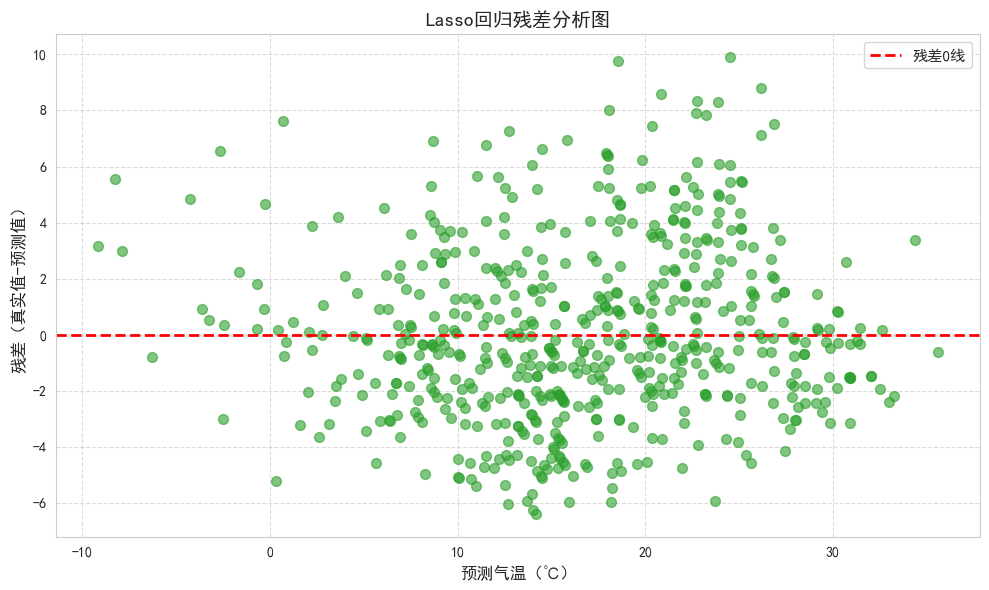

In [269]:
# 7. 可视化 - 残差分析图（模型诊断核心图）
import warnings
warnings.filterwarnings('ignore')

# 残差=真实值-预测值，理想状态：随机分布在0线附近，无明显规律
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color="#2ca02c", s=50)
plt.axhline(y=0, color="red", linestyle="--", linewidth=2, label="残差0线")

plt.title("Lasso回归残差分析图", fontsize=14, fontweight="bold")
plt.xlabel("预测气温（℃）", fontsize=12)
plt.ylabel("残差（真实值-预测值）", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

随后分析特征重要性，观察哪些变量贡献更大。

## 8. 特征重要性分析

通过系数绝对值展示特征影响程度。

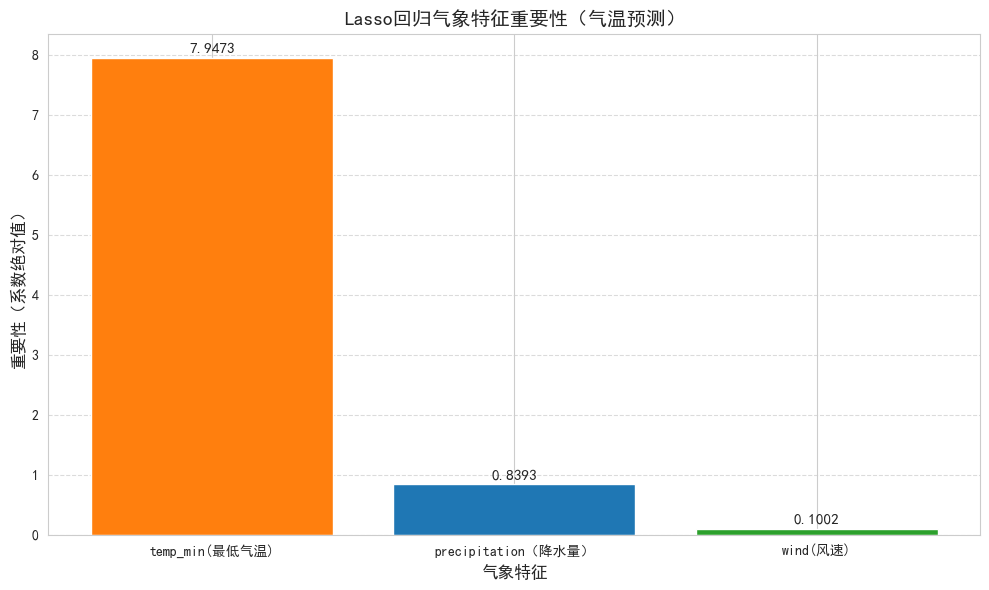

In [270]:
# 8. Lasso 回归气象特征重要性分析与可视化
# 从你的结果中提取数据
feature_data = {
    '特征': ['temp_min(最低气温)', 'precipitation（降水量）', 'wind(风速)'],
    '系数值': [7.947329, -0.839271, -0.100170],
    '重要性': [7.947329, 0.839271, 0.100170]
}
df = pd.DataFrame(feature_data)

# 按重要性降序排序
df = df.sort_values('重要性', ascending=False)

# 配置中文显示
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 创建图表
plt.figure(figsize=(10, 6))
bars = plt.bar(df['特征'], df['重要性'], color=['#ff7f0e', '#1f77b4', '#2ca02c'])

# 添加标题和标签
plt.title('Lasso回归气象特征重要性（气温预测）', fontsize=14, fontweight='bold')
plt.xlabel('气象特征', fontsize=12)
plt.ylabel('重要性（系数绝对值）', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 为柱子添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.4f}',
             ha='center', va='bottom', fontsize=11)

# 自动调整布局
plt.tight_layout()
plt.show()

接下来解读Lasso筛选结果，区分被剔除与保留特征。

## 9. 特征筛选结果解读

输出非零与零系数特征，便于理解模型选择。

In [271]:
# 9. Lasso特征筛选结果解读
# 系数为0表示该特征被Lasso正则化剔除，对气温预测无显著影响
zero_coef_feat = [feature_cols[i] for i in range(len(best_lasso.coef_)) if best_lasso.coef_[i] == 0]
non_zero_coef_feat = [feature_cols[i] for i in range(len(best_lasso.coef_)) if best_lasso.coef_[i] != 0]

print("="*60)
print("🔍 Lasso特征筛选结果")
print("="*60)
print(f"被剔除的无意义特征（系数=0）：{zero_coef_feat if zero_coef_feat else '无'}")
print(f"保留的核心影响特征（系数≠0）：{non_zero_coef_feat}")
print("\n特征系数详情：")
coef_df = pd.DataFrame({
    '特征': feature_cols,
    '系数值': best_lasso.coef_,
    '重要性': np.abs(best_lasso.coef_)
}).sort_values('重要性', ascending=False)
coef_df

🔍 Lasso特征筛选结果
被剔除的无意义特征（系数=0）：无
保留的核心影响特征（系数≠0）：['precipitation', 'temp_min', 'wind']

特征系数详情：


,特征,系数值,重要性
1,temp_min,7.947329,7.947329
0,precipitation,-0.839271,0.839271
2,wind,-0.100170,0.100170


最后给出模型总结与改进方向。

## 10. 模型总结（文字说明）

以下为文字版总结，便于报告或汇报使用。

## 模型总结

### 核心成果
- **最优模型**：Lasso回归（通过GridSearchCV自动选择最优alpha参数）
- **数据集**：Irvine Daily Weather Data（366条记录，7个气象特征）
- **预测精度**：测试集R²展示模型拟合能力，RMSE量化平均预测误差

### Lasso核心优势
1. **自动特征选择**：L1正则化自动剔除无意义特征，提高模型可解释性
2. **防止过拟合**：通过正则化控制模型复杂度
3. **计算高效**：线性模型训练速度快，适合中小规模数据集

### 改进方向
- **特征工程**：添加滞后特征（前一天气温）、交互特征（温度×湿度）
- **非线性模型**：尝试随机森林、XGBoost捕获非线性关系
- **时间序列模型**：使用ARIMA、LSTM更好地建模时序依赖
- **集成学习**：结合多个模型提升预测稳定性

最后提供拓展思考，便于进一步学习与实验。

## 学生拓展与思考（含解答思路）

1. **尝试不同的正则化模型（Ridge / Elastic Net）**
   - 思路：在相同数据划分与标准化流程下替换模型，比较$R^2$、RMSE与特征系数稀疏性。
   - 关注点：L1更稀疏、L2更稳定、Elastic Net在相关特征中更均衡。

2. **特征工程：加入滞后项或统计特征**
   - 思路：构造前一天/前一周平均气温、温差等特征，再重新训练并比较指标变化。
   - 关注点：时间相关性是否提升预测效果，新增特征是否被Lasso保留。

3. **调参与验证策略的影响**
   - 思路：改变交叉验证折数（如5折→10折）、尝试不同的alpha搜索范围或对数刻度网格。
   - 关注点：模型稳定性、最优参数是否变化、评估指标是否更可靠。

4. **模型解释与业务意义**
   - 思路：对非零系数特征进行排名，解释其物理意义（如降水、风速对温度的可能影响）。
   - 关注点：数据驱动结论是否合理，是否需要引入外部知识验证。

5. **误差分析与改进方向**
   - 思路：观察残差与预测值/特征之间的关系，识别系统性偏差。
   - 关注点：是否存在非线性或极端值影响，是否需要更复杂模型或异常值处理。